#### **Multiple Linear Regression :**

#### **House Price Prediction Using Multiple Features:**
- Predict house prices using area, bedrooms, bathrooms, parking, and location.

In [2]:
# Step No 1 : Import required libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score


In [3]:
# Step  No 2 : Data Loading and Exploration 
df = pd.read_csv("house_price_dataset.csv")
df 

,Area,Bedrooms,Bathrooms,Parking,Location,Price
0,1200,2,1,1,Urban,3500000
1,1500,3,2,1,Urban,4500000
2,1800,3,2,2,Urban,5500000
3,2000,4,3,2,Urban,6500000
4,2200,4,3,2,Urban,7200000
5,2500,5,4,3,Suburban,8500000
6,2700,5,4,3,Suburban,9200000
7,3000,6,5,3,Suburban,10500000
8,3200,6,5,4,Rural,11500000
9,3500,7,6,4,Rural,12500000


In [4]:
# Step No : 3 Understanding the Data 

# Display first rows
print(df.head())

# display statistics
print(df.describe())

# Display dataset information 
print(df.info())


   Area  Bedrooms  Bathrooms  Parking Location    Price
0  1200         2          1        1    Urban  3500000
1  1500         3          2        1    Urban  4500000
2  1800         3          2        2    Urban  5500000
3  2000         4          3        2    Urban  6500000
4  2200         4          3        2    Urban  7200000
              Area   Bedrooms  Bathrooms    Parking         Price
count    20.000000  20.000000  20.000000  20.000000  2.000000e+01
mean   2305.000000   4.500000   3.500000   2.500000  7.800000e+06
std     739.469938   1.538968   1.538968   1.051315  2.955993e+06
min    1100.000000   2.000000   1.000000   1.000000  3.200000e+06
25%    1750.000000   3.000000   2.000000   2.000000  5.375000e+06
50%    2300.000000   4.500000   3.500000   2.500000  7.750000e+06
75%    2925.000000   6.000000   5.000000   3.000000  1.027500e+07
max    3500.000000   7.000000   6.000000   4.000000  1.250000e+07
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19


In [5]:
# Step No 4 : Data Cleaning and Preprocessing 
# Checking Missing values 
print(df.isnull().sum())

# Checking Duplicate values
print(df.duplicated().sum())

# Remove duplicate rows 
df = df.drop_duplicates()

Area         0
Bedrooms     0
Bathrooms    0
Parking      0
Location     0
Price        0
dtype: int64
0


In [6]:
# Step No 5 : Categorical Data Encoding
# convert categorical data into numerical 
df = pd.get_dummies(df,columns=["Location"] , drop_first= True)

In [7]:
# Step No 6 : Features and Target Spliting 
#Define input features 
X = df.drop("Price" , axis=1)
# Define target variable 
y = df["Price"]

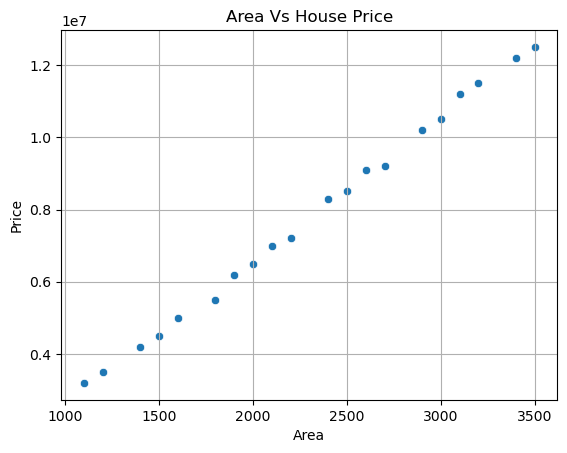

In [8]:
# Step No 7 : Visualization

# Scatter Plot Visualization 
sns.scatterplot(x = "Area" , y = "Price" , data = df)

# Plot Title
plt.title("Area Vs House Price")

# X-axis label 
plt.xlabel("Area")

# Y-axis label
plt.ylabel("Price")

# Enable Grid
plt.grid()

# Save fig 
plt.savefig("images/Area Vs House Price(Multiple Linear Regression).png")

# Display Plot 
plt.show()

In [9]:
# Step No 8 : Train Test Split for Model Evaluation
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42
)

In [10]:
# Step No 9 : Initialize Model
model = LinearRegression()

In [11]:
# Step No 10 : model training 
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# Steo No 11 : Prediction 
y_pred = model.predict(X_test)

# Print Prediction 
print("Predicted House Prices : ")
print(y_pred)

Predicted House Prices : 
[ 3330163.39400885 10071943.52873729  8394582.19865272  4500444.31704168]


In [13]:
# Step No 12 : Model Evaluation

# Calculate MAE
print("Mean Absolute Error : ")
print(mean_absolute_error(y_test , y_pred))

# Calculate MSE
print("Mean Squared Error : ")
print(mean_squared_error(y_test , y_pred))

# Calculate RMSE
print("Root Mean Squared Error : ")
print(np.sqrt(mean_squared_error(y_test , y_pred)))

# Calculate R2 Score 
print("R2 Score : ")
print(r2_score(y_test , y_pred))

Mean Absolute Error : 
98229.89823706355
Mean Squared Error : 
13547230571.616093
Root Mean Squared Error : 
116392.5709468439
R2 Score : 
0.998185689385236


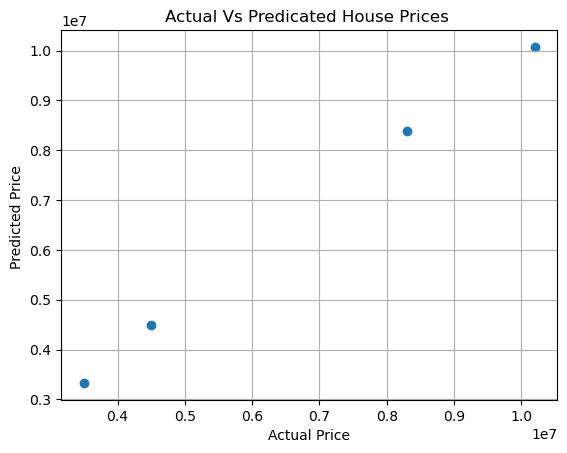

In [14]:
# Step No 13 : Actual vs Predicted Visualization
plt.scatter(y_test , y_pred)

# Plot title 
plt.title("Actual Vs Predicated House Prices ")

# X- axis label 
plt.xlabel("Actual Price")

# Y - axis label 
plt.ylabel("Predicted Price ")

# Enable grid 
plt.grid()

# save figure 
plt.savefig("images/Actual Vs Predicated House Prices(multiple linear regression).png")

# Show Plot 
plt.show()

In [16]:
# Step No 14 : User Input
area = float(input("Enter Area : "))

# Take bedrooms input 
bedrooms = int(input("Enter Bedrooms : "))

# Take Bathrooms input 
bathrooms = int(input("Enter Bathrooms : "))

# Take Parking Input 
parking = int(input("Enter Parking: "))

# Take Location Input 
location = int(input("Enter Location : "))

In [17]:
# Step No 15 : Prediction on User Input
user_data = pd.DataFrame({
    "Area": [area],
    "Bedrooms": [bedrooms],
    "Bathrooms": [bathrooms],
    "Parking" : [parking],
    "Location": [location]
})

# Encode categorical input 
user_data = pd.get_dummies(user_data , columns=["Location"] , drop_first=True )

# Match training columns 
user_data = user_data.reindex(columns=X.columns,fill_value=0)

# Predict house price 
result = model.predict(user_data)

In [18]:
# Step No 16 : Final Output
print(f"Predicted House Price is : ₹{result[0]:.2f}")

Predicted House Price is : ₹4554268.53
